# US equities panel: what the fitted models are worth before any of them is traded

Eight notebooks have now fitted models to this panel and written their validation predictions
down. None of them looked at another's results, and none of them chose anything. This notebook
is where they are read together for the first time - and it still chooses nothing, because a
ranking measure and a strategy are different questions and the second one is settled by a
backtest in [`16_backtest`](16_backtest.ipynb).

What it asks of the population, in order:

1. **Is it complete?** Every model notebook published a **named prediction set**: a fixed list
  of results, written down before fitting, that the run then had to fill. A set that came out
  short would otherwise look like a smaller experiment rather than a failed one, so the first
  thing here is to confirm each named set holds every member it promised.
2. **How well does each model rank the cross-section?** Measured by the information coefficient,
  with an interval around it that accounts for the dependence overlapping return windows create.
3. **Is a model's ranking ability steady, or does it come from one window?** A configuration
  whose skill sits in one fold and vanishes in the others has a mean that describes no period.
4. **Are two models actually different?** Two families can score alike and rank the same names,
  in which case the second one adds nothing a portfolio could use.
5. **How wide is the uncertainty around a prediction, and does that width hold up?** One of the
  allocators downstream sizes positions by it, so a width that is systematically too narrow
  would size positions too large.
6. **What does the causal estimate say, and why is it read apart from all of the above?**

**A note on what is being measured.** The **information coefficient** is the rank correlation,
across the stocks scored on one date, between what a model predicted and what those stocks went
on to earn. It says whether a model orders the cross-section correctly. It does not say what a
strategy trading that order would earn, and on a three-thousand-name panel the gap between the
two is turnover.

**Learning objectives.** By the end of this notebook you will be able to:

- Say why a comparison across models has to be made over a membership fixed in advance, and what
  a comparison over whatever happened to finish would hide.
- Read an information coefficient with an interval around it, and say what the interval is wider
  for than a plain standard error would be.
- Tell apart a model whose ranking ability is steady across validation windows from one whose
  average rests on a single window.
- Say when two models that score similarly are carrying the same information and when they are
  not, and why an average over shared dates is the comparison that answers it.
- Explain what a prediction interval calibrated on past residuals does and does not guarantee,
  and why that matters to an allocator that sizes by width.
- State why a causal estimate cannot be ranked alongside a predictive score.

**Book reference**: Chapters 11 to 15 for model interpretation, Chapter 16 for what happens to
these results next.

**Prerequisites**: the modelling notebooks - [`06_linear`](06_linear.ipynb) through
[`13b_ipca`](13b_ipca.ipynb) - have published their validation results and the named sets read
below, and [`14_causal_dml`](14_causal_dml.ipynb) has produced the causal result read in the
last section.

**What it writes**: nothing. It is read-only over the run log, and it selects nothing.

In [1]:
"""Read-only interpretation of the result sets the modelling notebooks published."""

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from ml4t.diagnostic.metrics import cross_sectional_ic_series

from case_studies.research import (
    CandidateSet,
    CausalResult,
    OfficialPopulation,
    PredictionResult,
    Study,
    open_study,
)
from case_studies.utils.backtest_runner import normalize_prediction_columns
from case_studies.utils.insight_chapter import conformal_coverage_for_selected_prediction
from case_studies.utils.registry import canonical_json, load_prediction_metrics
from utils.style import COLORS, add_message_title, show_with_alt, zero_line

In [2]:
CASE_STUDY_ID = "us_equities_panel"
EXECUTION_TIER = "canonical"
WORKSPACE = "experiments"
PREVIEW_LABELS = []
PREVIEW_FAMILIES = []
PREVIEW_CONFIG_NAMES = []
PREVIEW_MAX_PREDICTIONS = 0
PREVIEW_MAX_DIAGNOSTICS = 0
PREDICTION_SET_NAMES = [
    "us-equities-fwd-ret-1d-linear-v1",
    "us-equities-fwd-ret-5d-linear-v1",
    "us-equities-fwd-ret-21d-linear-v1",
    "us-equities-fwd-ret-1d-gbm-v1",
    "us-equities-fwd-ret-5d-gbm-v1",
    "us-equities-fwd-ret-21d-gbm-v1",
    "us-equities-fwd-ret-1d-tabular-dl-v1",
    "us-equities-fwd-ret-1d-nlinear-v1",
    "us-equities-fwd-ret-1d-lstm-v1",
    "us-equities-fwd-ret-1d-pca-v1",
    "us-equities-fwd-ret-1d-ipca-v1",
]

In [3]:
OFFICIAL_POPULATION_NAMES = [
    "us-equities-linear-checkpoints-v1",
    "us-equities-gbm-checkpoints-v1",
    "us-equities-tabular-dl-checkpoints-v1",
    "us-equities-nlinear-checkpoints-v1",
    "us-equities-lstm-checkpoints-v1",
    "us-equities-pca-checkpoints-v1",
    "us-equities-ipca-checkpoints-v1",
]

In [4]:
DIAGNOSTIC_SET_NAMES = [
    "us-equities-fwd-ret-1d-linear-diagnostics-v1",
    "us-equities-fwd-ret-5d-linear-diagnostics-v1",
    "us-equities-fwd-ret-21d-linear-diagnostics-v1",
    "us-equities-fwd-ret-1d-gbm-diagnostics-v1",
    "us-equities-fwd-ret-5d-gbm-diagnostics-v1",
    "us-equities-fwd-ret-21d-gbm-diagnostics-v1",
    "us-equities-fwd-ret-1d-tabular-dl-diagnostics-v1",
    "us-equities-fwd-ret-1d-nlinear-diagnostics-v1",
    "us-equities-fwd-ret-1d-lstm-diagnostics-v1",
    "us-equities-fwd-ret-1d-pca-diagnostics-v1",
    "us-equities-fwd-ret-1d-ipca-diagnostics-v1",
]
CAUSAL_LABELS = ["fwd_ret_1d"]

## 1. Opening the named sets, and checking each is whole

A result earns its place in the comparison by covering every stock-date-fold its own identity
promised, on the validation split, under this run's tier. A result that covers less is not a
weaker candidate: it is a candidate measured on a different sample, and averaging it beside the
others would make the ranking a statement about who finished rather than about who ranked well.

In [5]:
preview_filters = bool(PREVIEW_LABELS or PREVIEW_FAMILIES or PREVIEW_CONFIG_NAMES)
if EXECUTION_TIER == "canonical":
    if preview_filters or PREVIEW_MAX_PREDICTIONS or PREVIEW_MAX_DIAGNOSTICS:
        raise ValueError("Canonical analysis cannot declare preview reductions")
    for names, field in (
        (PREDICTION_SET_NAMES, "PREDICTION_SET_NAMES"),
        (DIAGNOSTIC_SET_NAMES, "DIAGNOSTIC_SET_NAMES"),
        (OFFICIAL_POPULATION_NAMES, "OFFICIAL_POPULATION_NAMES"),
    ):
        if not names or len(names) != len(set(names)):
            raise ValueError(f"{field} must contain unique names")
    # A name in both lists is a family with no bounded set, filled in with the full one, so
    # Sections 4 to 6 would load the whole population. Checked here because it is a statement
    # about the two lists and needs nothing from the registry.
    shared_names = sorted(set(DIAGNOSTIC_SET_NAMES) & set(PREDICTION_SET_NAMES))
    if shared_names:
        raise ValueError(
            f"these names are declared as both the full and the bounded set: {shared_names}"
        )
    study = Study.open(CASE_STUDY_ID)
elif EXECUTION_TIER == "preview":
    if not preview_filters or PREVIEW_MAX_PREDICTIONS < 1 or PREVIEW_MAX_DIAGNOSTICS < 1:
        raise ValueError(
            "Preview analysis requires a catalog filter and explicit prediction limits"
        )
    if PREVIEW_MAX_DIAGNOSTICS > PREVIEW_MAX_PREDICTIONS:
        raise ValueError("Preview diagnostics cannot exceed the preview prediction population")
    study = open_study(
        CASE_STUDY_ID,
        execution_tier=EXECUTION_TIER,
        workspace=Path(os.environ.get("ML4T_OUTPUT_DIR") or WORKSPACE),
    )
else:
    raise ValueError(f"Unsupported execution tier: {EXECUTION_TIER!r}")

include_preview = EXECUTION_TIER == "preview"
# Metrics are read from the tier's own storage. A preview run writes its rows to an isolated
# registry while still reading the released labels and features, so the lookup has to be pointed
# at the registry the rows came from rather than at the released one.
metrics_case_dir = study.storage_root(EXECUTION_TIER)
prediction_sets = ()
diagnostic_sets = ()
official_populations = ()

In [6]:
if EXECUTION_TIER == "canonical":
    prediction_sets = tuple(CandidateSet.one(study, name=name) for name in PREDICTION_SET_NAMES)
    diagnostic_sets = tuple(CandidateSet.one(study, name=name) for name in DIAGNOSTIC_SET_NAMES)
    official_populations = tuple(
        OfficialPopulation.one(study, name=name) for name in OFFICIAL_POPULATION_NAMES
    )
    for population in official_populations:
        if population.member_kind != "prediction":
            raise ValueError(f"{population.hash} is not a prediction population")
        population.require_complete()

In [7]:
if EXECUTION_TIER == "canonical":
    identity_protocol_fields = {"label_artifact", "feature_artifacts", "cv"}
    for declared_set in (*prediction_sets, *diagnostic_sets):
        if declared_set.member_kind != "prediction":
            raise ValueError(f"{declared_set.hash} contains {declared_set.member_kind} results")
        comparable_fields = set(declared_set.comparison_contract.get("comparable_fields", ()))
        variable_identity_fields = identity_protocol_fields & comparable_fields
        if variable_identity_fields:
            raise ValueError(
                f"{declared_set.hash} varies identity fields {sorted(variable_identity_fields)}"
            )
        declared_protocol = declared_set.comparison_contract.get("protocol", {})
        missing_identity_fields = {
            field for field in identity_protocol_fields if not declared_protocol.get(field)
        }
        if missing_identity_fields:
            raise ValueError(
                f"{declared_set.hash} lacks identity fields {sorted(missing_identity_fields)}"
            )
        if (
            declared_protocol.get("split") != "validation"
            or declared_protocol.get("execution_tier") != "canonical"
        ):
            raise ValueError(f"{declared_set.hash} is not a canonical validation set")

In [8]:
if EXECUTION_TIER == "canonical":
    prediction_members = tuple(
        member for declared_set in prediction_sets for member in declared_set.members
    )
    diagnostic_members = tuple(
        member for declared_set in diagnostic_sets for member in declared_set.members
    )
    prediction_set_by_member = {
        member: declared_set.name
        for declared_set in prediction_sets
        for member in declared_set.members
    }
    if len(prediction_members) != len(set(prediction_members)):
        raise ValueError("full prediction sets overlap")
    if len(diagnostic_members) != len(set(diagnostic_members)):
        raise ValueError("diagnostic prediction sets overlap")
    if not set(diagnostic_members) <= set(prediction_members):
        raise ValueError("diagnostic results must be members of the full prediction sets")
    official_members = tuple(
        member for population in official_populations for member in population.members
    )
    if len(official_members) != len(set(official_members)):
        raise ValueError("official checkpoint populations overlap")
    if set(official_members) != set(prediction_members):
        raise ValueError("official checkpoint population differs from the full prediction sets")

In [9]:
if EXECUTION_TIER == "canonical":
    for diagnostic_set in diagnostic_sets:
        diagnostic_protocol = canonical_json(diagnostic_set.comparison_contract["protocol"])
        matching_full_sets = [
            full_set
            for full_set in prediction_sets
            if canonical_json(full_set.comparison_contract["protocol"]) == diagnostic_protocol
            and set(diagnostic_set.members) <= set(full_set.members)
        ]
        if len(matching_full_sets) != 1:
            raise ValueError(
                f"{diagnostic_set.hash} resolved {len(matching_full_sets)} matching full sets"
            )
        # `<=` above finds which full set this one came from and establishes no bounding, since
        # a set is a subset of itself. A family publishing one member has nothing to bound, so
        # the strict test applies only where the full set holds more than one.
        full_members = set(matching_full_sets[0].members)
        if len(full_members) > 1 and set(diagnostic_set.members) == full_members:
            raise ValueError(
                f"{diagnostic_set.name} bounds nothing: it is all {len(full_members)} members of "
                f"{matching_full_sets[0].name}"
            )

In [10]:
if EXECUTION_TIER == "canonical":
    set_rows = [
        {
            "role": role,
            "name": declared_set.name,
            "set_hash": declared_set.hash,
            "members": len(declared_set.members),
        }
        for role, declared_sets in (
            ("strategy handoff", prediction_sets),
            ("bounded diagnostics", diagnostic_sets),
        )
        for declared_set in declared_sets
    ]
else:
    preview_selection = study.predictions.table(include_preview=True).filter(
        (pl.col("execution_tier") == "preview")
        & (pl.col("split") == "validation")
        & pl.col("complete")
    )
    if PREVIEW_LABELS:
        preview_selection = preview_selection.filter(pl.col("label").is_in(PREVIEW_LABELS))
    if PREVIEW_FAMILIES:
        preview_selection = preview_selection.filter(pl.col("family").is_in(PREVIEW_FAMILIES))
    if PREVIEW_CONFIG_NAMES:
        preview_selection = preview_selection.filter(
            pl.col("config_name").is_in(PREVIEW_CONFIG_NAMES)
        )
    preview_selection = preview_selection.sort(
        "label", "family", "config_name", "checkpoint_value", "prediction_hash"
    ).head(PREVIEW_MAX_PREDICTIONS)
    if preview_selection.is_empty():
        raise ValueError("Preview analysis selection is empty")

In [11]:
if EXECUTION_TIER == "preview":
    prediction_members = tuple(preview_selection.get_column("prediction_hash"))
    diagnostic_members = prediction_members[:PREVIEW_MAX_DIAGNOSTICS]
    preview_group_by_member = {
        row["prediction_hash"]: f"preview:{row['label']}:{row['cv_identity']}"
        for row in preview_selection.iter_rows(named=True)
    }
    prediction_set_by_member = dict(preview_group_by_member)
    set_rows = [
        {
            "role": role,
            "name": name,
            "set_hash": None,
            "members": len(members),
        }
        for role, name, members in (
            ("strategy handoff", "preview-selection", prediction_members),
            ("bounded diagnostics", "preview-diagnostics", diagnostic_members),
        )
    ]

set_table = pl.DataFrame(set_rows)
set_table

role,name,set_hash,members
str,str,str,i64
"""strategy handoff""","""us-equities-fwd-ret-1d-linear-…","""55d64275dfd6""",16
"""strategy handoff""","""us-equities-fwd-ret-5d-linear-…","""e7b744f380d5""",16
"""strategy handoff""","""us-equities-fwd-ret-21d-linear…","""6e8179623f0a""",16
"""strategy handoff""","""us-equities-fwd-ret-1d-gbm-v1""","""55e19e98194d""",150
"""strategy handoff""","""us-equities-fwd-ret-5d-gbm-v1""","""d6f72d818b3a""",150
…,…,…,…
"""bounded diagnostics""","""us-equities-fwd-ret-1d-tabular…","""33b7ba8aa280""",1
"""bounded diagnostics""","""us-equities-fwd-ret-1d-nlinear…","""2b1d25deb946""",1
"""bounded diagnostics""","""us-equities-fwd-ret-1d-lstm-di…","""0b99e3574904""",1


## 2. Every result complete, and scored where it said it would be

A model fitted for 200 epochs and the same model at epoch 50 are two candidates, not one
candidate measured twice, so the checkpoint travels with the configuration everywhere below. The
catalog keeps both alongside the hashes that produced them, and nothing is scored until its
coverage has been checked - a metric computed on an incomplete set is the one number in this
notebook that would look entirely normal.

In [12]:
catalog_rows = []
prediction_results = {}
prediction_identities = set()

In [13]:
for prediction_hash in prediction_members:
    result = study.results.open(prediction_hash, include_preview=include_preview)
    if not isinstance(result, PredictionResult):
        raise TypeError(f"{prediction_hash} is not a prediction result")
    if result.execution_tier != EXECUTION_TIER or not result.complete:
        raise ValueError(f"{prediction_hash} is not a complete {EXECUTION_TIER} result")

    record = result.registry_record()
    if record["split"] != "validation":
        raise ValueError(f"{prediction_hash} is not a validation result")
    if not record["checkpoint_kind"]:
        raise ValueError(f"{prediction_hash} has no checkpoint kind")
    coverage = result.coverage()
    if coverage is None or coverage["status"] != "complete":
        raise ValueError(f"{prediction_hash} has incomplete coverage")

    training = study.results.open(record["training_hash"], include_preview=include_preview)
    specification = training.spec()
    identity = (
        record["training_hash"],
        record["checkpoint_kind"],
        record["checkpoint_value"],
    )
    if identity in prediction_identities:
        raise ValueError("prediction set repeats a configuration-checkpoint identity")
    prediction_identities.add(identity)
    catalog_rows.append(
        {
            "prediction_hash": prediction_hash,
            "training_hash": record["training_hash"],
            "compatible_set": prediction_set_by_member[prediction_hash],
            "family": specification["family"],
            "config_name": specification["config_name"],
            "label": specification["label"],
            "checkpoint_kind": record["checkpoint_kind"],
            "checkpoint_value": record["checkpoint_value"],
            "n_predictions": coverage["n_actual"],
            "n_folds": coverage["n_folds_actual"],
        }
    )
    prediction_results[prediction_hash] = result

In [14]:
catalog = pl.DataFrame(catalog_rows).sort(
    ["label", "family", "config_name", "checkpoint_kind", "checkpoint_value", "prediction_hash"]
)
catalog

prediction_hash,training_hash,compatible_set,family,config_name,label,checkpoint_kind,checkpoint_value,n_predictions,n_folds
str,str,str,str,str,str,str,i64,i64,i64
"""885ca061472c""","""69645aa3f18e""","""us-equities-fwd-ret-1d-lstm-v1""","""deep_learning""","""lstm_h64""","""fwd_ret_1d""","""epoch""",5,6653283,16
"""dcf0b52d6d76""","""69645aa3f18e""","""us-equities-fwd-ret-1d-lstm-v1""","""deep_learning""","""lstm_h64""","""fwd_ret_1d""","""epoch""",10,6653283,16
"""6f2ff30262cf""","""69645aa3f18e""","""us-equities-fwd-ret-1d-lstm-v1""","""deep_learning""","""lstm_h64""","""fwd_ret_1d""","""epoch""",15,6653283,16
"""f8b7fc2416d9""","""69645aa3f18e""","""us-equities-fwd-ret-1d-lstm-v1""","""deep_learning""","""lstm_h64""","""fwd_ret_1d""","""epoch""",20,6653283,16
"""0e2e83212a74""","""69645aa3f18e""","""us-equities-fwd-ret-1d-lstm-v1""","""deep_learning""","""lstm_h64""","""fwd_ret_1d""","""epoch""",25,6653283,16
…,…,…,…,…,…,…,…,…,…
"""edae58022822""","""b990256a7da3""","""us-equities-fwd-ret-5d-linear-…","""linear""","""ridge_a1000.0""","""fwd_ret_5d""","""final""",null,7160171,16
"""864ef6528201""","""34d746eeba03""","""us-equities-fwd-ret-5d-linear-…","""linear""","""ridge_a10000.0""","""fwd_ret_5d""","""final""",null,7160171,16
"""ea59c6db1d9f""","""7b3ec95eb00f""","""us-equities-fwd-ret-5d-linear-…","""linear""","""ridge_a100000.0""","""fwd_ret_5d""","""final""",null,7160171,16


## 3. How well each model ranks the cross-section

On each decision date, rank the stocks by what the model predicted, rank them by what they went
on to earn, and correlate the two rankings: that is the **information coefficient** for that
date. Averaging it over every date in the validation period gives each date the same weight,
whatever the size of its cross-section.

The interval around that average is wider than an ordinary one, and deliberately. A five-session
forward return measured every session shares four of its five days with the next one, so
consecutive observations are not independent and a plain standard error would treat far more
information as present than there is. The correction used here - **HAC**, for
heteroskedasticity- and autocorrelation-consistent - widens the interval by what that overlap
costs.

In [15]:
metric_rows = []
required_metrics = {
    "ic_mean_daily",
    "ic_ci_lo",
    "ic_ci_hi",
    "ic_t_hac",
    "ic_p_hac",
    "ic_n_days",
    "ic_pct_positive",
}

for row in catalog.iter_rows(named=True):
    metrics = load_prediction_metrics(
        CASE_STUDY_ID,
        prediction_hash=row["prediction_hash"],
        case_dir=metrics_case_dir,
    )
    if metrics.height != 1 or not required_metrics <= set(metrics.columns):
        raise ValueError(f"missing exact daily metrics for {row['prediction_hash']}")
    values = metrics.row(0, named=True)
    if any(values[name] is None or not np.isfinite(values[name]) for name in required_metrics):
        raise ValueError(f"non-finite daily metric for {row['prediction_hash']}")
    metric_rows.append({**row, **{name: values[name] for name in required_metrics}})

performance = pl.DataFrame(metric_rows).sort(
    ["label", "family", "config_name", "checkpoint_kind", "checkpoint_value", "prediction_hash"]
)
performance.select(
    "label",
    "family",
    "config_name",
    "checkpoint_kind",
    "checkpoint_value",
    "ic_mean_daily",
    "ic_ci_lo",
    "ic_ci_hi",
    "ic_n_days",
    "ic_pct_positive",
)

label,family,config_name,checkpoint_kind,checkpoint_value,ic_mean_daily,ic_ci_lo,ic_ci_hi,ic_n_days,ic_pct_positive
str,str,str,str,i64,f64,f64,f64,f64,f64
"""fwd_ret_1d""","""deep_learning""","""lstm_h64""","""epoch""",5,0.006822,0.002961,0.010684,4031.0,0.523195
"""fwd_ret_1d""","""deep_learning""","""lstm_h64""","""epoch""",10,0.001863,-0.002318,0.006043,4031.0,0.515257
"""fwd_ret_1d""","""deep_learning""","""lstm_h64""","""epoch""",15,0.00171,-0.002265,0.005686,4031.0,0.502605
"""fwd_ret_1d""","""deep_learning""","""lstm_h64""","""epoch""",20,0.000989,-0.002884,0.004862,4031.0,0.505582
"""fwd_ret_1d""","""deep_learning""","""lstm_h64""","""epoch""",25,0.0002,-0.003496,0.003895,4031.0,0.505582
…,…,…,…,…,…,…,…,…,…
"""fwd_ret_5d""","""linear""","""ridge_a1000.0""","""final""",null,0.013636,0.007397,0.019875,4027.0,0.554259
"""fwd_ret_5d""","""linear""","""ridge_a10000.0""","""final""",null,0.014197,0.007892,0.020502,4027.0,0.555749
"""fwd_ret_5d""","""linear""","""ridge_a100000.0""","""final""",null,0.016907,0.010419,0.023395,4027.0,0.563198


The population is several hundred candidates, because a checkpoint is one of them, so a chart
with a labelled row per candidate would be a strip several metres long. Two things are worth
seeing across that many, and each is a distribution:

**Where each family sits.** The left panel puts every candidate's mean daily IC in its family's
column, one column per label and family. Read the height of a column's cloud, not any one point:
a family whose whole cloud sits above zero ranked the cross-section, and one straddling zero did
not.

**How much of that is measurable.** The right panel is the half-width of each candidate's
interval, on the same vertical scale. Where a family's half-widths are as large as the spread of
its point estimates in the left panel, the ordering inside that family is not something the data
distinguishes, however cleanly the table sorts.

Neither panel selects anything, and the exact interval for any one candidate is in the frame
above.

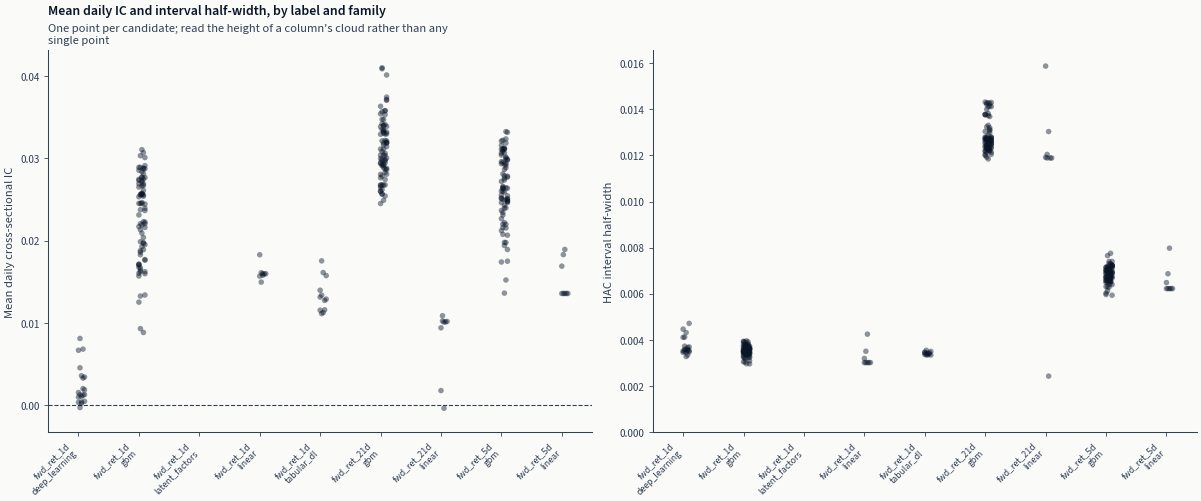

In [16]:
plot_performance = performance.with_columns(
    half_width=(pl.col("ic_ci_hi") - pl.col("ic_ci_lo")) / 2
)
columns = (
    plot_performance.select("label", "family").unique().sort("label", "family").rows(named=True)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, column_name, axis_label in zip(
    axes,
    ("ic_mean_daily", "half_width"),
    ("Mean daily cross-sectional IC", "HAC interval half-width"),
    strict=True,
):
    for position, column in enumerate(columns):
        values = plot_performance.filter(
            (pl.col("label") == column["label"]) & (pl.col("family") == column["family"])
        ).get_column(column_name)
        # Deterministic spread within a column so overlapping candidates stay countable; the
        # horizontal position carries no meaning of its own.
        jitter = (values.arg_sort().to_numpy() % 9 - 4) / 40
        ax.scatter(
            position + jitter,
            values.to_numpy(),
            alpha=0.45,
            s=16,
            color=COLORS["blue"],
            edgecolors="none",
        )
    ax.set_xticks(
        range(len(columns)),
        [f"{column['label']}\n{column['family']}" for column in columns],
        rotation=45,
        ha="right",
        fontsize=7,
    )
    ax.set_xlim(-0.5, len(columns) - 0.5)
    ax.set_ylabel(axis_label)
zero_line(axes[0])
axes[1].set_ylim(bottom=0)
add_message_title(
    axes[0],
    "Mean daily IC and interval half-width, by label and family",
    subtitle=(
        "One point per candidate; read the height of a column's cloud rather than any single point"
    ),
)
# The alt text counts rather than asserts: whether any family's cloud clears zero is a fact about
# the frame, and a panel described as separating the families when it does not is a claim the data
# refutes.
_clear = plot_performance.group_by("label", "family").agg(
    above=(pl.col("ic_ci_lo") > 0).sum(), total=pl.len()
)
_n_any = int((_clear.get_column("above") > 0).sum())
show_with_alt(
    fig,
    "Two strip plots side by side, one column per label and model family, sharing that column "
    "order. The left panel places every candidate at its mean daily cross-sectional information "
    "coefficient, with a dashed line at zero; the right places the same candidates at the "
    "half-width of their heteroskedasticity-and-autocorrelation-consistent interval, on an axis "
    "starting at zero. Points are spread horizontally within a column so overlapping candidates "
    f"stay visible. Counted from the underlying frame, {_n_any} of {_clear.height} label-family "
    "columns hold at least one candidate whose interval lies entirely above zero.",
)

## 4. Whether that ranking ability holds across windows

An average over sixteen windows says nothing about whether the sixteen agreed. A configuration
that ranked the cross-section well in one year and not at all in the others has a mean no reader
could have traded through, and it looks identical in the table above to one that worked steadily.
The fold summaries below separate them.

This is where raw predictions are read rather than registry metrics, which is why it runs over
the bounded diagnostic subset rather than the whole population. Each model notebook publishes
that subset as one member per label and family - its diagnostic configuration at its last
checkpoint - and the bound is arithmetic rather than taste. One prediction frame on this panel
is over seven million rows and about 225 MB held in memory, every diagnostic frame is resident at once
because Section 5 joins them pairwise, and the full population is several hundred members.

In [17]:
KEYS = ["symbol", "timestamp", "fold_id"]
diagnostic_frames = {}
daily_rows = []

for prediction_hash in diagnostic_members:
    result = prediction_results[prediction_hash]
    frame = normalize_prediction_columns(result.load())
    required_columns = {*KEYS, "y_true", "y_score"}
    if not required_columns <= set(frame.columns):
        raise ValueError(f"{prediction_hash} lacks canonical prediction columns")
    if frame.select(KEYS).is_duplicated().any():
        raise ValueError(f"{prediction_hash} repeats canonical prediction keys")
    if frame.select(pl.any_horizontal(pl.col("y_true", "y_score").is_null())).to_series().any():
        raise ValueError(f"{prediction_hash} contains null predictions")
    if frame.select(pl.any_horizontal(~pl.col("y_true", "y_score").is_finite())).to_series().any():
        raise ValueError(f"{prediction_hash} contains non-finite predictions")

    meta = catalog.filter(pl.col("prediction_hash") == prediction_hash).row(0, named=True)
    model_id = f"{meta['label']} | {meta['family']}/{meta['config_name']} [{prediction_hash[:8]}]"
    diagnostic_frames[prediction_hash] = frame
    for fold_id in sorted(frame["fold_id"].unique().to_list()):
        fold_frame = frame.filter(pl.col("fold_id") == fold_id)
        daily = cross_sectional_ic_series(
            fold_frame,
            fold_frame,
            pred_col="y_score",
            ret_col="y_true",
            date_col="timestamp",
            entity_col="symbol",
            method="spearman",
            min_obs=5,
        ).drop_nulls("ic")
        daily_rows.append(
            daily.with_columns(
                pl.lit(model_id).alias("model_id"),
                pl.lit(prediction_hash).alias("prediction_hash"),
                pl.lit(fold_id).alias("fold_id"),
            )
        )

In [18]:
daily_ic = pl.concat(daily_rows, how="vertical_relaxed")
if daily_ic.select(["prediction_hash", "fold_id", "timestamp"]).is_duplicated().any():
    raise ValueError("daily IC keys are not unique")

fold_ic = (
    daily_ic.group_by("model_id", "prediction_hash", "fold_id")
    .agg(
        pl.col("ic").mean().alias("mean_daily_ic"),
        pl.len().alias("n_decision_dates"),
    )
    .sort("model_id", "fold_id")
)
fold_ic

model_id,prediction_hash,fold_id,mean_daily_ic,n_decision_dates
str,str,i32,f64,u32
"""fwd_ret_1d | deep_learning/lst…","""60e71cd89767""",0,-0.001974,252
"""fwd_ret_1d | deep_learning/lst…","""60e71cd89767""",1,0.010023,252
"""fwd_ret_1d | deep_learning/lst…","""60e71cd89767""",2,0.010673,252
"""fwd_ret_1d | deep_learning/lst…","""60e71cd89767""",3,-0.000387,252
"""fwd_ret_1d | deep_learning/lst…","""60e71cd89767""",4,0.002448,252
…,…,…,…,…
"""fwd_ret_5d | linear/ols [b64f4…","""b64f415b53ae""",11,0.001258,252
"""fwd_ret_5d | linear/ols [b64f4…","""b64f415b53ae""",12,0.000466,252
"""fwd_ret_5d | linear/ols [b64f4…","""b64f415b53ae""",13,0.001253,252


## 5. Whether two models carry the same information

Two configurations that score alike are not two pieces of evidence if they are ranking the same
names in the same order. A portfolio holding both would then be taking one bet at twice the
size, which is the failure this section exists to catch.

Every pair drawn from the same label is compared, which pairs the families against each other:
a label fixes what the models were predicting and which folds they were scored on, so two
results under it are answering the same question and their orderings can be set side by side.
Pairs that cross labels are not compared, because a one-day and a twenty-one-day forward return
are different questions and a correlation between them measures nothing.

The comparison is made only on the observations both results actually cover, one date at a time,
and averaged over dates. Two things are checked before any correlation is computed: that the
join is one-to-one, because a join that quietly multiplies rows makes two models look more alike
than they are, and that both artifacts carry the same realized return for every shared
observation, because if they disagree about what happened they are not comparable at all.

Coverage differs between families and the frame says by how much. A sequence model scores only
the stock-dates where sixty consecutive sessions were available, so it covers fewer rows than a
model on the flat table, and `n_shared_rows` is what a reader checks before reading a
correlation as a statement about the whole panel.

In [19]:
correlation_rows = []
diagnostic_hashes = list(diagnostic_members)
label_by_member = {
    row["prediction_hash"]: row["label"]
    for row in catalog.select("prediction_hash", "label").iter_rows(named=True)
}


def prediction_display_id(prediction_hash):
    meta = catalog.filter(pl.col("prediction_hash") == prediction_hash).row(0, named=True)
    return f"{meta['label']} | {meta['family']}/{meta['config_name']} [{prediction_hash[:8]}]"

In [20]:
def summarize_prediction_pair(left_hash, right_hash):
    left = diagnostic_frames[left_hash].select(
        *KEYS,
        pl.col("y_true").alias("y_true_left"),
        pl.col("y_score").alias("score_left"),
    )
    right = diagnostic_frames[right_hash].select(
        *KEYS,
        pl.col("y_true").alias("y_true_right"),
        pl.col("y_score").alias("score_right"),
    )
    paired = left.join(right, on=KEYS, how="inner", validate="1:1")
    if paired.is_empty() or paired.height > min(left.height, right.height):
        raise ValueError(f"invalid paired coverage for {left_hash} and {right_hash}")
    if not np.allclose(
        paired["y_true_left"].cast(pl.Float64).to_numpy(),
        paired["y_true_right"].cast(pl.Float64).to_numpy(),
        rtol=1e-6,
        atol=1e-8,
    ):
        raise ValueError(f"realized returns disagree for {left_hash} and {right_hash}")
    daily_correlation = paired.group_by("timestamp", "fold_id").agg(
        pl.corr(
            pl.col("score_left").rank(method="average"),
            pl.col("score_right").rank(method="average"),
        ).alias("correlation")
    )
    return {
        "left": prediction_display_id(left_hash),
        "right": prediction_display_id(right_hash),
        "mean_daily_correlation": daily_correlation["correlation"].drop_nulls().mean(),
        "n_shared_rows": paired.height,
        "n_decision_dates": daily_correlation["correlation"].drop_nulls().len(),
    }

In [21]:
# `left_index + 1`: a result against itself correlates at one on every date.
for left_index, left_hash in enumerate(diagnostic_hashes):
    for right_hash in diagnostic_hashes[left_index + 1 :]:
        if label_by_member[left_hash] != label_by_member[right_hash]:
            continue
        correlation_rows.append(summarize_prediction_pair(left_hash, right_hash))

# The schema is declared so that a run whose diagnostic members share no label - a preview holding
# one - produces an empty frame with columns rather than a frame with none, which `sort` would
# raise on.
correlations = pl.DataFrame(
    correlation_rows,
    schema={
        "left": pl.String,
        "right": pl.String,
        "mean_daily_correlation": pl.Float64,
        "n_shared_rows": pl.Int64,
        "n_decision_dates": pl.Int64,
    },
).sort("left", "right")
correlations

left,right,mean_daily_correlation,n_shared_rows,n_decision_dates
str,str,f64,i64,i64
"""fwd_ret_1d | deep_learning/lst…","""fwd_ret_1d | latent_factors/ip…",0.034886,6653283,4031
"""fwd_ret_1d | deep_learning/lst…","""fwd_ret_1d | latent_factors/pc…",-0.00023,4624831,4031
"""fwd_ret_1d | deep_learning/nli…","""fwd_ret_1d | deep_learning/lst…",0.037857,6653283,4031
"""fwd_ret_1d | deep_learning/nli…","""fwd_ret_1d | latent_factors/ip…",0.179901,6653283,4031
"""fwd_ret_1d | deep_learning/nli…","""fwd_ret_1d | latent_factors/pc…",0.018093,4624831,4031
…,…,…,…,…
"""fwd_ret_1d | tabular_dl/tabm_s…","""fwd_ret_1d | deep_learning/nli…",0.073497,6653283,4031
"""fwd_ret_1d | tabular_dl/tabm_s…","""fwd_ret_1d | latent_factors/ip…",0.121677,7170323,4031
"""fwd_ret_1d | tabular_dl/tabm_s…","""fwd_ret_1d | latent_factors/pc…",-0.001613,4728969,4031


## 6. How wide the uncertainty is, and whether the width is calibrated

The width measured here is the one the `conformal_weighted` allocator sizes positions with:
calibrated per symbol on every absolute residual known at `t - h`, where `h` is that label's
horizon in data steps, falling back to a quantile pooled over every symbol where one has too
few residuals of its own. A decision is covered when its absolute residual falls inside that
half-width; the embargo is what keeps a residual that resolves after the decision out of the
calibration behind it, whatever order the fold identifiers are in.

Read it as a diagnostic of residual dispersion, not a guarantee: split conformal's
finite-sample coverage needs exchangeable residuals, return residuals are not, and nothing in
the allocation path reads an interval or a coverage level.

In [22]:
coverage_frames = []

for prediction_hash in diagnostic_members:
    meta = catalog.filter(pl.col("prediction_hash") == prediction_hash).row(0, named=True)
    training_spec = study.results.open(
        meta["training_hash"], include_preview=include_preview
    ).spec()
    coverage_frames.append(
        conformal_coverage_for_selected_prediction(
            {
                "case_study": CASE_STUDY_ID,
                "family": meta["family"],
                "config_name": meta["config_name"],
                "prediction_hash": prediction_hash,
                "spec_json": json.dumps(training_spec),
            }
        ).with_columns(pl.lit(meta["label"]).alias("label"))
    )

conformal_coverage = pl.concat(coverage_frames, how="vertical_relaxed").sort(
    "label", "family", "config_name", "nominal_level"
)
conformal_coverage.select(
    "label",
    "family",
    "config_name",
    "prediction_hash",
    "nominal_level",
    "empirical_coverage",
    "mean_interval_width_frac_std",
)

case_studies/utils/conformal.py:515: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  targets.join_asof(


label,family,config_name,prediction_hash,nominal_level,empirical_coverage,mean_interval_width_frac_std
str,str,str,str,f64,f64,f64
"""fwd_ret_1d""","""deep_learning""","""lstm_h64""","""60e71cd89767""",0.8,0.840047,2.387096
"""fwd_ret_1d""","""deep_learning""","""lstm_h64""","""60e71cd89767""",0.9,0.921519,3.384361
"""fwd_ret_1d""","""deep_learning""","""lstm_h64""","""60e71cd89767""",0.95,0.959519,4.479547
"""fwd_ret_1d""","""deep_learning""","""nlinear""","""58b626e5853a""",0.8,0.838804,2.223783
"""fwd_ret_1d""","""deep_learning""","""nlinear""","""58b626e5853a""",0.9,0.921145,3.156245
…,…,…,…,…,…,…
"""fwd_ret_5d""","""gbm""","""default_mse""","""a3c6a6673d5f""",0.9,0.918418,3.474232
"""fwd_ret_5d""","""gbm""","""default_mse""","""a3c6a6673d5f""",0.95,0.956447,4.562305
"""fwd_ret_5d""","""linear""","""ols""","""b64f415b53ae""",0.8,0.840362,2.364034


## 7. The causal estimate, read on its own terms

Everything above asks how well a model orders the cross-section. The estimate below asks
something the rest of this notebook cannot: whether moving the treatment would move the outcome,
after removing what the declared confounders explain. That is not a score, it ranks nothing, and
there is no axis on which it could be placed beside an information coefficient - which is why it
is read here on its own and never enters a prediction set.

In [23]:
causal_columns = [
    "causal_hash",
    "label",
    "treatment",
    "confounders",
    "dml_effect",
    "dml_se_hac",
    "p_value_hac",
    "naive_effect",
    "refutation_p",
    "n_obs",
]

if len(CAUSAL_LABELS) != len(set(CAUSAL_LABELS)):
    raise ValueError("causal labels must be unique")

if CAUSAL_LABELS:
    causal_rows = []
    for label in CAUSAL_LABELS:
        result = CausalResult.one(study, label=label, execution_tier=EXECUTION_TIER)
        if not result.complete or result.execution_tier != EXECUTION_TIER:
            raise ValueError(
                f"{label} does not resolve to a complete {EXECUTION_TIER} causal result"
            )
        computation = result.spec["computation"]
        estimand = computation["estimand"]
        causal_rows.append(
            {
                "causal_hash": result.hash,
                "label": result.spec["label"],
                "treatment": estimand["treatment"],
                "confounders": estimand["confounders"],
                **{name: result.metrics[name] for name in causal_columns[4:]},
            }
        )
    causal_results = pl.DataFrame(causal_rows).sort("label", "causal_hash")
else:
    causal_results = pl.DataFrame(schema={name: pl.String for name in causal_columns})

causal_results

causal_hash,label,treatment,confounders,dml_effect,dml_se_hac,p_value_hac,naive_effect,refutation_p,n_obs
str,str,str,list[str],f64,f64,f64,f64,f64,i64
"""8ffe890496bd""","""fwd_ret_1d""","""past_ret_12m_skip""","[""vol_21d"", ""illiq_rank"", ""volume_ratio""]",0.000211,0.000309,0.495102,0.000183,1.0,7911763


## What goes on to the backtest

Every member of every full prediction set, unfiltered. Nothing measured above narrows the list:
a model that ranked poorly here is still backtested, because ranking accuracy and strategy
performance are different questions and this notebook is not qualified to answer the second.
[`16_backtest`](16_backtest.ipynb) runs an equal-weight backtest for each one, and the single
selection is made on validation backtest Sharpe in the strategy notebooks after it.

In [24]:
print(
    "Prediction candidate sets for backtesting: "
    f"{set_table.filter(pl.col('role') == 'strategy handoff').height}"
)
print(f"Members handed off: {len(prediction_members)}")
set_table.filter(pl.col("role") == "strategy handoff")

Prediction candidate sets for backtesting: 11
Members handed off: 564


role,name,set_hash,members
str,str,str,i64
"""strategy handoff""","""us-equities-fwd-ret-1d-linear-…","""55d64275dfd6""",16
"""strategy handoff""","""us-equities-fwd-ret-5d-linear-…","""e7b744f380d5""",16
"""strategy handoff""","""us-equities-fwd-ret-21d-linear…","""6e8179623f0a""",16
"""strategy handoff""","""us-equities-fwd-ret-1d-gbm-v1""","""55e19e98194d""",150
"""strategy handoff""","""us-equities-fwd-ret-5d-gbm-v1""","""d6f72d818b3a""",150
…,…,…,…
"""strategy handoff""","""us-equities-fwd-ret-1d-tabular…","""f30d95e1fe5d""",24
"""strategy handoff""","""us-equities-fwd-ret-1d-nlinear…","""0e1eadd71b87""",20
"""strategy handoff""","""us-equities-fwd-ret-1d-lstm-v1""","""9be9cc17555f""",20


## What to notice

**Fix the population before measuring it.** Comparing whatever results happen to be in a registry
lets the comparison change every time something is refitted, and lets a family that failed
halfway look like a family that was cheaper to run. Naming the membership in advance and
checking it here is what makes "this model ranked above that one" a statement about the models.

**An average over dates needs an interval that knows the dates are not independent.** A
five-session forward return measured every session shares four of its five days with the next
one. Treating those as independent observations makes an interval too narrow and a t-statistic
too large, on every model equally, so the ordering is unaffected and the significance is not.

**A mean IC and a stable IC are different claims.** Averaging across folds hides which folds
contributed, and a configuration that ranks well in one window and not at all in the others has
an average that describes no period a reader could have traded through.

**Two models scoring alike is not two pieces of evidence.** Where predictions correlate closely
on the dates they share, a portfolio holding both gets one signal at twice the weight. The
pairwise comparison is what separates agreement from redundancy, and it has to be computed on
shared observations with the panel keys intact - a join that quietly multiplies rows would make
two models look more alike than they are.

**A calibrated interval is a description, not a promise.** Split conformal's coverage guarantee
needs residuals that are exchangeable, and return residuals are not - they cluster in volatility
and share a market factor. Read the coverage here as a diagnostic of how residual dispersion
moves, which is what an allocator sizing by width is exposed to.

**A causal estimate is answering a different question.** It estimates what a change in the
treatment does, after removing what the declared confounders explain. It is not a score that
ranks names, so it cannot be placed on the same table as one, and it never enters a prediction
set.

**Nothing here selects.** Ranking accuracy and strategy performance are different questions, and
the second is decided on validation backtest Sharpe in the notebooks that follow.

**Known limitations.** Every number above comes from the validation folds, which have been read
many times over by the time a case study reaches this notebook; the holdout is opened once, for
the replay of whatever validation selects, and it is the only thing here that speaks to
performance rather than to selection.